# Testing Co-Kriging on Darcy flow

Using the solution of the finite differences solver. 

In [ ]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

In [3]:
# loading the Darcy solution
usoln = np.loadtxt('DarcySoln.txt')

In [4]:
# Defining the domain
N = 400
x = np.linspace(0, 1, N)                # not inclusive of the last point
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y, indexing='ij')

## Random Observations 
`nobs` random observations in the domain, uniform randomly chosen.

In [5]:
# Random observation locations
nobs = 0
xidx = np.random.choice(N, nobs)
yidx = np.random.choice(N, nobs)
rObs = np.column_stack([x[xidx], y[yidx]])
ruObs = usoln[xidx, yidx]                     # correct
# ruObs = usoln[yidx, xidx]                       # incorrect

In [ ]:
# TEST : to check the Ordering of the observation points
# fig, axs = plt.subplots(1, 2, figsize=(12,5))
# cm = axs[0].scatter(rObs[:,0], rObs[:,1], c = ruObs)            # ordering of the observations.
# axs[0].set_title('Randomly picked points')
# fig.colorbar(cm)    
# cm = axs[1].contourf(X,Y,usoln, levels = 100)                   # True soln.   
# axs[1].set_title('True solution')
# fig.colorbar(cm)
# plt.show()

## Collocation locations

In [42]:
# nc = 20                     # 20 X 20 uniform grid
# Cx = np.linspace(0, 1, nc)
# Cy = np.linspace(0, 1, nc)
# Cx, Cy = np.meshgrid(C[:,0], C[:,1])
# C = np.column_stack([Cx.flatten(), Cy.flatten()])

# uniform random sampling
nc = 400 
np.random.seed(0)
C = np.random.uniform(0, 1, (nc, 2))

In [ ]:
# TEST : C locations
# plt.scatter(C[:,0], C[:,1], marker = 'X', c = 'black')
# plt.show()

## Boundary condition as exact observations

In [44]:
step = 10
# x = 0, 1
BxL, BxR = np.meshgrid([0,1], 
                        y[::step])
Bx = np.column_stack([BxL.flatten(),
                     BxR.flatten()])
# y = 0, 1 
ByD, ByU = np.meshgrid(x[::step], 
                    [0,1])
By = np.column_stack([ByD.flatten(),
                     ByU.flatten()]) 

In [ ]:
# TEST : B locations
# plt.scatter(Bx[:,0], Bx[:,1], marker = 'X', c = 'red')
# plt.scatter(By[:,0], By[:,1], marker = 'X', c = 'green')
# plt.show()

In [45]:
# full vector of observation locations
Obs = np.vstack([rObs, Bx, By])
uObs = np.vstack([*ruObs, *np.zeros(Bx.shape[0]), *np.zeros(By.shape[0])])

## Prediction locations 

In [46]:
step = 15      
Pred = np.column_stack([X[::step, ::step].flatten(), Y[::step, ::step].flatten()])

In [ ]:
# TEST : Prediction locations
# plt.scatter(Pred[:,0], Pred[:,1])
# plt.show()

## Kernel functions

In [10]:
# zero-dim r function. 
def r0dim(xa, xb, t):
    diff = (xa - xb)/t
    return np.sum(diff**2)  

# multi-dim r function. 
def rndim(xa, xb, t):
    '''
    FUNCTION TO COMPUTE: 

    r(xa, xb) = -0.5 * (xa - xb)^T diag(t^-2) (xa - xb) 
    '''
    diff = xa-xb
    # if np.ndim(xa) != 0:
    Sigma = np.diag(1/np.asarray(t)**2)                          # Rescaling matrix
    r = diff.T @ Sigma @ diff 
    return -r/2

# first and second order r derivatives: Stationary kernels 
def dr(xa, xb, t, i: int, num_b: int):
    neg_factor = (-1)**(num_b + 1)                              # (-1)^{#b + 1}
    return neg_factor * (1/t[i]**2) * (xa[i] - xb[i])

def d2r(xa, xb, t, i: int, num_b):
    neg_factor = (-1)**(num_b + 1)                              # (-1)^{#b + 1}
    return neg_factor * (1/t[i]**2)

# differentiated K functions: Squared exponential
def K(r, s=1.0):
    return s**2 * np.exp(r)

# final covariance functions

# undifferentiated
def k(xa, xb, t, s=1.0):
    rdist = rndim(xa, xb, t)
    return K(rdist, s)

# first derivative(s)
def kx(xa, xb, t, s=1.0, b=0):
    rdist = rndim(xa, xb, t)
    val1 = K(rdist, s)
    val2 = dr(xa, xb, t, i=0, num_b=b)
    return val1 * val2

def ky(xa, xb, t, s=1.0, b=0):
    rdist = rndim(xa, xb, t)
    val1 = K(rdist, s)
    val2 = dr(xa, xb, t, i=1, num_b=b)
    return val1 * val2

# second derivative(s)
def kxx(xa, xb, t, s=1.0, b=[0,0]):
    rdist = rndim(xa, xb, t)
    
    kp = K(rdist, s)
    kp2 = K(rdist, s)

    num_b = np.sum(np.array(b))
    D2r = d2r(xa, xb, t, i=0, num_b=num_b)

    Dr1 = dr(xa, xb, t, i=0, num_b=b[0])                
    Dr2 = dr(xa, xb, t, i=0, num_b=b[1])
    val1 = kp * D2r 
    val2 = kp2 * Dr1 * Dr2

    return val1 + val2

def kyy(xa, xb, t, s=1.0, b=[0,0]):
    rdist = rndim(xa, xb, t)
    
    kp = K(rdist, s)
    kp2 = K(rdist, s)
    
    num_b = np.sum(np.array(b))
    D2r = d2r(xa, xb, t, i=1, num_b=num_b)
    
    Dr1 = dr(xa, xb, t, i=1, num_b=b[0])                
    Dr2 = dr(xa, xb, t, i=1, num_b=b[1])
    val1 = kp * D2r 
    val2 = kp2 * Dr1 * Dr2
    
    return val1 + val2

def kxy(xa, xb, t, s=1.0, b=[0,0]):
    rdist = rndim(xa, xb, t)
    
    kp2 = K(rdist, s)
    Dr1 = dr(xa, xb, t, i=0, num_b=b[0])                
    Dr2 = dr(xa, xb, t, i=1, num_b=b[1])
 
    val = kp2 * Dr1 * Dr2
    return val

# third order derivatives
def kxyy(xa, xb, t, s=1.0, b=[0,0,0]):
    rdist = rndim(xa, xb, t)

    kp2 = K(rdist)
    kp3 = K(rdist)
    
    Dr1 = dr(xa, xb, t, i=0, num_b=b[0])
    Dr2 = dr(xa, xb, t, i=1, num_b=b[1])
    Dr3 = dr(xa, xb, t, i=1, num_b=b[2])

    # num_b = np.sum(np.array(b))
    D2r1 = d2r(xa, xb, t, i=1, num_b=b[1]+b[2])
    # D2r2 = 0
    # D2r3 = 0

    val1 = kp2 * D2r1 * Dr1
    val2 = kp3 * Dr1 * Dr2 * Dr3
    return val1 + val2

def kyyx(xa, xb, t, s=1.0, b=[0,0,0]):
    rdist = rndim(xa, xb, t)

    kp2 = K(rdist)
    kp3 = K(rdist)
    
    Dr1 = dr(xa, xb, t, i=1, num_b=b[0])
    Dr2 = dr(xa, xb, t, i=1, num_b=b[1])
    Dr3 = dr(xa, xb, t, i=0, num_b=b[2])

    # num_b = np.sum(np.array(b))
    D2r3 = d2r(xa, xb, t, i=1, num_b=b[0]+b[1])
    # D2r1 = 0
    # D2r2 = 0

    val1 = kp2 * D2r3 * Dr3
    val2 = kp3 * Dr1 * Dr2 * Dr3
    return val1 + val2

def kxxy(xa, xb, t, s = 1.0, b = [0,0,0]):
    rdist = rndim(xa, xb, t)

    kp2 = K(rdist)
    kp3 = K(rdist)
    
    Dr1 = dr(xa, xb, t, i=0, num_b=b[0])
    Dr2 = dr(xa, xb, t, i=0, num_b=b[1])
    Dr3 = dr(xa, xb, t, i=1, num_b=b[2])

    # num_b = np.sum(np.array(b))
    D2r3 = d2r(xa, xb, t, i=0, num_b=b[0]+b[1])
    # D2r1 = 0
    # D2r2 = 0

    val1 = kp2 * D2r3 * Dr3
    val2 = kp3 * Dr1 * Dr2 * Dr3
    return val1 + val2

def kyxx(xa, xb, t, s = 1.0, b = [0,0,0]):
    rdist = rndim(xa, xb, t)
    
    kp2 = K(rdist)
    kp3 = K(rdist)
    
    Dr1 = dr(xa, xb, t, i=1, num_b=b[0])
    Dr2 = dr(xa, xb, t, i=0, num_b=b[1])
    Dr3 = dr(xa, xb, t, i=0, num_b=b[2])
    
    # num_b = np.sum(np.array(b))
    # D2r3 = 0
    D2r1 = d2r(xa, xb, t, i=0, num_b=b[1]+b[2])
    # D2r2 = 0
    
    val1 = kp2 * D2r1 * Dr1
    val2 = kp3 * Dr1 * Dr2 * Dr3
    return val1 + val2

def kxxx(xa, xb, t, s=1.0, b = [0,0,0]):
    rdist = rndim(xa, xb, t)
    
    kp2 = K(rdist)
    kp3 = K(rdist)
    
    Dr1 = dr(xa, xb, t, i=0, num_b=b[0])
    Dr2 = dr(xa, xb, t, i=0, num_b=b[1])
    Dr3 = dr(xa, xb, t, i=0, num_b=b[2])
    
    # num_b = np.sum(np.array(b))
    D2r1 = d2r(xa, xb, t, i=0, num_b=b[1]+b[2])
    D2r2 = d2r(xa, xb, t, i=0, num_b=b[0]+b[2])
    D2r3 = d2r(xa, xb, t, i=0, num_b=b[0]+b[1])
    
    val1 = kp2 * (D2r1 * Dr1 + D2r2 * Dr2 + D2r3 * Dr3) 
    val2 = kp3 * Dr1 * Dr2 * Dr3
    return val1 + val2

def kyyy(xa, xb, t, s=1.0, b = [0,0,0]):
    rdist = rndim(xa, xb, t)
    
    kp2 = K(rdist)
    kp3 = K(rdist)
    
    Dr1 = dr(xa, xb, t, i=1, num_b=b[0])
    Dr2 = dr(xa, xb, t, i=1, num_b=b[1])
    Dr3 = dr(xa, xb, t, i=1, num_b=b[2])
    
    # num_b = np.sum(np.array(b))
    D2r1 = d2r(xa, xb, t, i=1, num_b=b[1]+b[2])
    D2r2 = d2r(xa, xb, t, i=1, num_b=b[0]+b[2])
    D2r3 = d2r(xa, xb, t, i=1, num_b=b[0]+b[1])
    
    val1 = kp2 * (D2r1 * Dr1 + D2r2 * Dr2 + D2r3 * Dr3) 
    val2 = kp3 * Dr1 * Dr2 * Dr3
    return val1 + val2


# fourth order derivatives
def kyyyy(xa, xb, t, s=1.0, b=[0,0,0,0]):
    rdist = rndim(xa, xb, t)

    kp2 = K(rdist)
    kp3 = K(rdist)
    kp4 = K(rdist)
    
    D2r1 = d2r(xa, xb, t, i=1, num_b=b[0]+b[1])
    D2r2 = d2r(xa, xb, t, i=1, num_b=b[0]+b[2])
    D2r3 = d2r(xa, xb, t, i=1, num_b=b[0]+b[3])
    D2r4 = d2r(xa, xb, t, i=1, num_b=b[1]+b[2])
    D2r5 = d2r(xa, xb, t, i=1, num_b=b[1]+b[3])
    D2r6 = d2r(xa, xb, t, i=1, num_b=b[2]+b[3])

    Dr1 = dr(xa, xb, t, i=1, num_b=b[0])
    Dr2 = dr(xa, xb, t, i=1, num_b=b[1])
    Dr3 = dr(xa, xb, t, i=1, num_b=b[2])
    Dr4 = dr(xa, xb, t, i=1, num_b=b[3])

    val1 = kp2 * ((D2r1 * D2r6) + (D2r2 * D2r5) + (D2r3 * D2r4))
    val2 = kp3 * ((D2r1 * Dr3 * Dr4) + (D2r2 * Dr2 * Dr4) + (D2r3 * Dr2 * Dr3) + (D2r4 * Dr1 * Dr4) + (D2r5 * Dr1 * Dr3) + (D2r6 * Dr1 * Dr2))
    val3 = kp4 * Dr1 * Dr2 * Dr3 * Dr4
    return val1 + val2 + val3

def kxxxx(xa, xb, t, s=1.0, b=[0,0,0,0]):
    rdist = rndim(xa, xb, t)
    
    kp2 = K(rdist)
    kp3 = K(rdist)
    kp4 = K(rdist)
    
    D2r1 = d2r(xa, xb, t, i=0, num_b=b[0]+b[1])
    D2r2 = d2r(xa, xb, t, i=0, num_b=b[0]+b[2])
    D2r3 = d2r(xa, xb, t, i=0, num_b=b[0]+b[3])
    D2r4 = d2r(xa, xb, t, i=0, num_b=b[1]+b[2])
    D2r5 = d2r(xa, xb, t, i=0, num_b=b[1]+b[3])
    D2r6 = d2r(xa, xb, t, i=0, num_b=b[2]+b[3])

    Dr1 = dr(xa, xb, t, i=0, num_b=b[0])
    Dr2 = dr(xa, xb, t, i=0, num_b=b[1])
    Dr3 = dr(xa, xb, t, i=0, num_b=b[2])
    Dr4 = dr(xa, xb, t, i=0, num_b=b[3])

    val1 = kp2 * ((D2r1 * D2r6) + (D2r2 * D2r5) + (D2r3 * D2r4))
    val2 = kp3 * ((D2r1 * Dr3 * Dr4) + (D2r2 * Dr2 * Dr4) + (D2r3 * Dr2 * Dr3) + (D2r4 * Dr1 * Dr4) + (D2r5 * Dr1 * Dr3) + (D2r6 * Dr1 * Dr2))
    val3 = kp4 * Dr1 * Dr2 * Dr3 * Dr4
    return val1 + val2 + val3


def kxxyy(xa, xb, t, s=1.0, b=[0,0,0,0]):
    rdist = rndim(xa, xb, t)
    
    kp2 = K(rdist)
    kp3 = K(rdist)
    kp4 = K(rdist)
    
    D2r1 = d2r(xa, xb, t, i=0, num_b=b[0]+b[1])
    D2r2 = 0
    D2r3 = 0
    D2r4 = 0
    D2r5 = 0
    D2r6 = d2r(xa, xb, t, i=1, num_b=b[2]+b[3])
    
    Dr1 = dr(xa, xb, t, i=0, num_b=b[0])
    Dr2 = dr(xa, xb, t, i=0, num_b=b[1])
    Dr3 = dr(xa, xb, t, i=1, num_b=b[2])
    Dr4 = dr(xa, xb, t, i=1, num_b=b[3])
    
    val1 = kp2 * ((D2r1 * D2r6) + (D2r2 * D2r5) + (D2r3 * D2r4))
    val2 = kp3 * ((D2r1 * Dr3 * Dr4) + (D2r2 * Dr2 * Dr4) + (D2r3 * Dr2 * Dr3) + (D2r4 * Dr1 * Dr4) + (D2r5 * Dr1 * Dr3) + (D2r6 * Dr1 * Dr2))
    val3 = kp4 * Dr1 * Dr2 * Dr3 * Dr4
    return val1 + val2 + val3

def kyyxx(xa, xb, t, s=1.0, b=[0,0,0,0]):
    rdist = rndim(xa, xb, t)
    
    kp2 = K(rdist)
    kp3 = K(rdist)
    kp4 = K(rdist)
    
    D2r1 = d2r(xa, xb, t, i=1, num_b=b[0]+b[1])
    D2r2 = 0
    D2r3 = 0
    D2r4 = 0
    D2r5 = 0
    D2r6 = d2r(xa, xb, t, i=0, num_b=b[2]+b[3])
    
    Dr1 = dr(xa, xb, t, i=1, num_b=b[0])
    Dr2 = dr(xa, xb, t, i=1, num_b=b[1])
    Dr3 = dr(xa, xb, t, i=0, num_b=b[2])
    Dr4 = dr(xa, xb, t, i=0, num_b=b[3])
    
    val1 = kp2 * ((D2r1 * D2r6) + (D2r2 * D2r5) + (D2r3 * D2r4))
    val2 = kp3 * ((D2r1 * Dr3 * Dr4) + (D2r2 * Dr2 * Dr4) + (D2r3 * Dr2 * Dr3) + (D2r4 * Dr1 * Dr4) + (D2r5 * Dr1 * Dr3) + (D2r6 * Dr1 * Dr2))
    val3 = kp4 * Dr1 * Dr2 * Dr3 * Dr4
    return val1 + val2 + val3


## Covariance matrices

In [47]:
# diffusivity function (& its derivatives)
def a(x, y):
    return np.exp(-x)*np.sin(y) + 0.1
    # return np.exp(np.sin(x) * np.cos(y))
    # return np.exp(-10*np.sin(x))
    # return np.exp(-10*np.cos(y))
def ax(x, y):
    return -np.exp(-x)*np.sin(y)
    # return a(x, y) * np.cos(x) * np.cos(y)
    # return -10*np.exp(-10*np.sin(x))*np.cos(x) 
    # return 0

def ay(x, y):
    return np.exp(-x)*np.cos(y)
    # return -a(x, y) * np.sin(y) * np.sin(x)
    # return 0
    # return 10 * np.sin(y) * np.exp(-10*np.cos(y))

A = np.diag(np.array(list(map(a, C[:,0], C[:,1]))))
Ax = np.diag(np.array(list(map(ax, C[:,0], C[:,1]))))
Ay = np.diag(np.array(list(map(ay, C[:,0], C[:,1]))))

U = (np.kron(Ax, [1,0,0,0]) + np.kron(Ay, [0,1,0,0]) + np.kron(A, [0,0,1,0]) + np.kron(A, [0,0,0,1])).T 

# theta param. 
theta = [0.1, 0.1]

# Creating a grid-like array with elements like M_ij = [Obs_i, Obs_j] 
ObsObs = np.array(list(product(Obs, Obs)))            # Filled as row-first, column-second: M_ij = ObsObs[i*Obs.shape[0]+j] 

# Creating a grid-like array with elements like M_ij = [Obs_i, C_j] 
ObsC = np.array(list(product(Obs, C)))                # Filled as row-first, column-second: M_ij = ObsC[i*C.shape[0]+j]

# Creating a grid-like array with elements like M_ij = [C_i, C_j] 
CC = np.array(list(product(C, C)))                    # Filled as row-first, column-second: M_ij = CC[i*C.shape[0]+j]

In [48]:
# covariance matrices
#=============================
def KObsObs(theta):
    t = theta                                                       # kernel params. 
    # Upper triangular indices
    _i, _j = np.triu_indices(n = Obs.shape[0])
    TriIndices = _i * Obs.shape[0] + _j
    
    # Covariance computations
    ktheta = lambda u, udash: k(u, udash, t=t)                      # lambda function to create a new function that takes only locations as args.
    CovU = np.array(list(map(ktheta, ObsObs[TriIndices, 0],     
                                ObsObs[TriIndices, 1])))
    K = np.zeros((Obs.shape[0], Obs.shape[0]))                      # Initializing the K matrix
    K[_i, _j] = CovU                                                # Upper triangular entries
    K = (K + K.T) - np.diag(np.diag(K))                             # Symmetric matrix properties
    return K
#=============================

#=============================
def KObsC(theta):
    t = theta                                                       # kernel params.
    # Covariance computations
    kxdashtheta = lambda u, udash: kx(u, udash, t=t, b=1)               # Differentiating with respect to the second arg.
    kydashtheta = lambda u, udash: ky(u, udash, t=t, b=1)               # Differentiating with respect to the second arg.
    kxxdashtheta = lambda u, udash: kxx(u, udash, t=t, b=[1,1])         # Differentiating with respect to the second arg.
    kyydashtheta = lambda u, udash: kyy(u, udash, t=t, b=[1,1])         # Differentiating with respect to the second arg.

    Cov1 = np.array(list(map(kxdashtheta, ObsC[:,0],
                             ObsC[:,1]))).reshape(Obs.shape[0], C.shape[0])
    Cov2 = np.array(list(map(kydashtheta, ObsC[:,0],
                                 ObsC[:,1]))).reshape(Obs.shape[0], C.shape[0])
    Cov3 = np.array(list(map(kxxdashtheta, ObsC[:,0],
                                 ObsC[:,1]))).reshape(Obs.shape[0], C.shape[0])
    Cov4 = np.array(list(map(kyydashtheta, ObsC[:,0],
                                 ObsC[:,1]))).reshape(Obs.shape[0], C.shape[0])

    K = np.kron(Cov1, [1,0,0,0]) + np.kron(Cov2, [0,1,0,0]) + np.kron(Cov3, [0,0,1,0]) + np.kron(Cov4, [0,0,0,1])
    K = K @ U

    return K
#=============================

#=============================
def KCC(theta):
    t = theta                                                       # kernel params.
    # Covariance computations
    kxxdashtheta = lambda u, udash: kxx(u, udash, t=t, b=[0,1])         # Differentiating with respect to the second arg.
    kxydashtheta = lambda u, udash: kxy(u, udash, t=t, b=[0,1])         # Differentiating with respect to the second arg.
    kxxxdashtheta = lambda u, udash: kxxx(u, udash, t=t, b=[0,1,1])     # Differentiating with respect to the second arg.
    kxyydashtheta = lambda u, udash: kxyy(u, udash, t=t, b=[0,1,1])     # Differentiating with respect to the second arg.

    kyxdashtheta = lambda u, udash: kxy(u, udash, t=t, b=[0,1])         # kyx = kxy
    kyydashtheta = lambda u, udash: kyy(u, udash, t=t, b=[0,1])
    kyxxdashtheta = lambda u, udash: kyxx(u, udash, t=t, b=[0,1,1])
    kyyydashtheta = lambda u, udash: kyyy(u, udash, t=t, b=[0,1,1])

    kxxxdtheta = lambda u, udash: kxxx(u, udash, t=t, b=[0,0,1])
    kxxydtheta = lambda u, udash: kxxy(u, udash, t=t, b=[0,0,1])
    kxxxdxdtheta = lambda u, udash: kxxxx(u, udash, t=t, b=[0,0,1,1])
    kxxydydtheta = lambda u, udash: kxxyy(u, udash, t=t, b=[0,0,1,1])

    kyyxdtheta = lambda u, udash: kyyx(u, udash, t=t, b=[0,0,1])
    kyyydtheta = lambda u, udash: kyyy(u, udash, t=t, b=[0,0,1])
    kyyxdxdtheta = lambda u, udash: kyyxx(u, udash, t=t, b=[0,0,1,1])
    kyyydydtheta = lambda u, udash: kyyyy(u, udash, t=t, b=[0,0,1,1])

    klist = [kxxdashtheta, kxydashtheta, kxxxdashtheta, kxyydashtheta,
             kyxdashtheta, kyydashtheta, kyxxdashtheta, kyyydashtheta,
             kxxxdtheta, kxxydtheta, kxxxdxdtheta, kxxydydtheta,
             kyyxdtheta, kyyydtheta, kyyxdxdtheta, kyyydydtheta]
    
    K = np.zeros((C.shape[0], C.shape[0]))

    for kernel, _ in zip(klist, range(16)):
        e = np.zeros((4,4))
        e[int(_/4), _%4] = 1
        Cov = np.array(list(map(kernel, CC[:,0], 
                                CC[:,1]))).reshape(C.shape[0], 
                                                   C.shape[0])
        Cov = U.T @ np.kron(Cov, e) @ U 
        K += Cov 
    
    return K


K11 = KObsObs(theta)
K12 = KObsC(theta); K21 = K12.T
K22 = KCC(theta)

Kplus = np.block([[K11, K12],
                [K21, K22]])


In [49]:
# Obs. - C - Pred. locations
ObsPred = np.array(list(product(Obs, Pred)))                        # Filled as row-first, column-second: M_ij = ObsPred[i*Obs.shape[0]+j]
CPred = np.array(list(product(C, Pred)))                            # Filled as row-first, column-second: M_ij = ObsPred[i*C.shape[0]+j]

#===============================
def HObsPred(theta):                    
    t = theta                                                       # kernel params.
    # Covariance computations
    ktheta = lambda u, udash: k(u, udash, t=t)                      # lambda function to create a new function that takes only locations as args.
    H = np.array(list(map(ktheta, ObsPred[:,0],
                                    ObsPred[:,1])))
    return H.reshape(Obs.shape[0], Pred.shape[0])
#===============================

#===============================
def HCPred(theta):
    t = theta                                                       # kernel params.
    # Covariance computations
    kxtheta = lambda u, udash: kx(u, udash, t=t, b=0)               # Differentiating with respect to the second arg.
    kytheta = lambda u, udash: ky(u, udash, t=t, b=0)               # Differentiating with respect to the second arg.
    kxxtheta = lambda u, udash: kxx(u, udash, t=t, b=[0,0])         # Differentiating with respect to the second arg.
    kyytheta = lambda u, udash: kyy(u, udash, t=t, b=[0,0])         # Differentiating with respect to the second arg.

    Cov1 = np.array(list(map(kxtheta, CPred[:,0],
                             CPred[:,1]))).reshape(C.shape[0], Pred.shape[0])
    Cov2 = np.array(list(map(kytheta, CPred[:,0],
                                 CPred[:,1]))).reshape(C.shape[0], Pred.shape[0])
    Cov3 = np.array(list(map(kxxtheta, CPred[:,0],
                                 CPred[:,1]))).reshape(C.shape[0], Pred.shape[0])
    Cov4 = np.array(list(map(kyytheta, CPred[:,0],
                                 CPred[:,1]))).reshape(C.shape[0], Pred.shape[0]) 
    
    K = (np.kron(Cov1.T, [1,0,0,0]) + np.kron(Cov2.T, [0,1,0,0]) + np.kron(Cov3.T, [0,0,1,0]) + np.kron(Cov4.T, [0,0,0,1])).T
    K = U.T @ K

    return K
#===============================

H1 = HObsPred(theta)
H2 = HCPred(theta)

Hplus = np.block([[H1],
                [H2]])

In [50]:
# [Yhat] Co-Kriging predictions
Id = np.eye(Kplus.shape[0]); nugget=1e-10
Kplusinv = np.linalg.solve(Kplus + (nugget*Id), Id)
uFULLObs = np.vstack([*uObs, *np.ones(C.shape[0])])     # Random obs. (if any) + Boundary conditions + RHS of Darcy  
uhat = Hplus.T @ Kplusinv @ uFULLObs


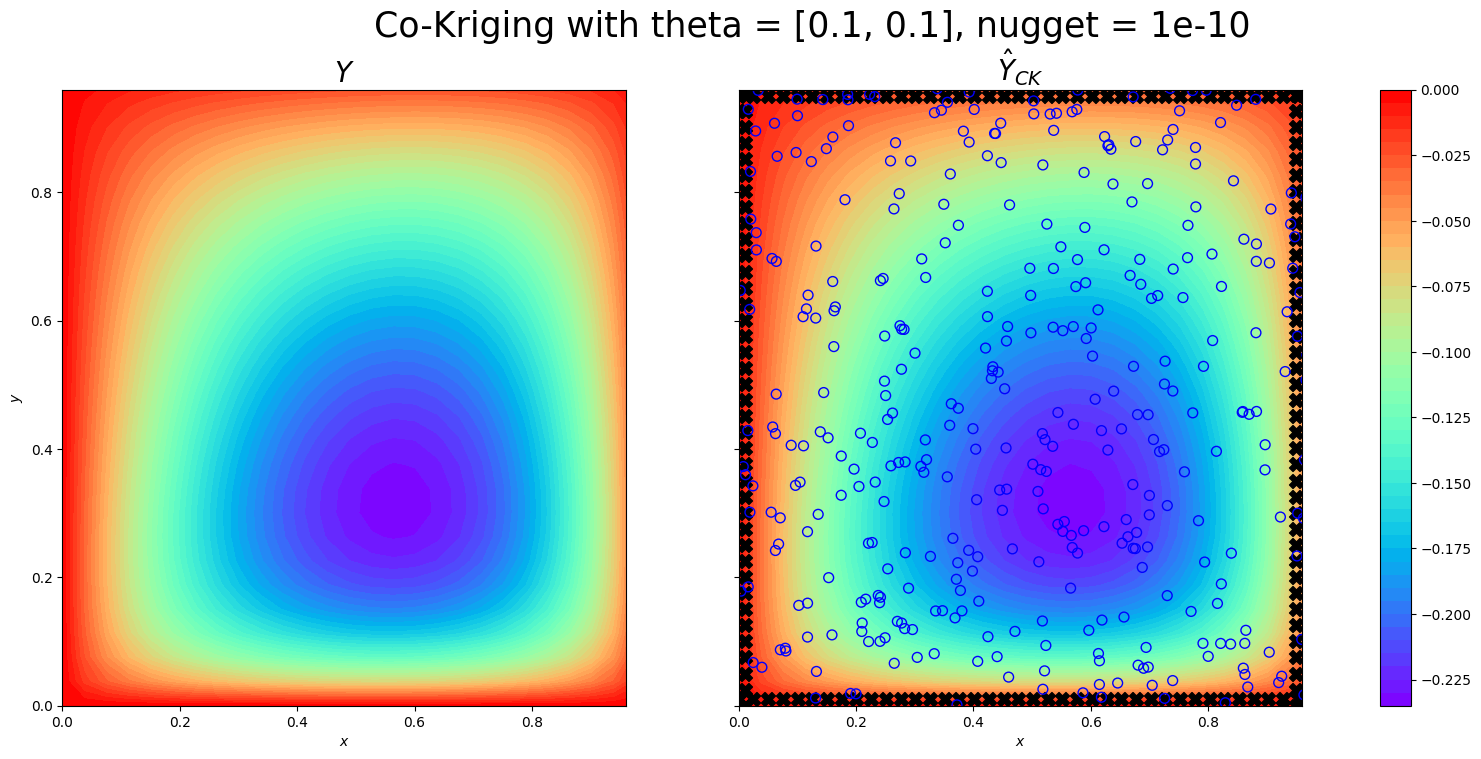

In [97]:
# Visualizing the results 
fig, axs = plt.subplots(1, 2, figsize = (20, 8), sharey=True)
grid = int(np.sqrt(uhat.shape[0]))
cm = axs[1].contourf(X[::step, ::step], Y[::step, ::step], uhat.reshape(grid, grid), cmap='rainbow', levels = 50)
# cm.set_clim(-0.6, 0)
# fig.colorbar(cm)
axs[1].scatter(rObs[:,0], rObs[:,1], marker = 'x', c = 'black', s = 100)            # Random observation locations (if any)

axs[1].scatter(Obs[Obs[:,0]<=0.01,0] + 0.01, Obs[Obs[:,0]<=0.01,1], marker = 'X', c = 'black', s = 100)           # Boundary conditions
axs[1].scatter(Obs[Obs[:,0]>=0.96,0] - 0.05, Obs[Obs[:,0]>=0.96,1], marker = 'X', c = 'black', s = 100)           # Boundary conditions
axs[1].scatter(Obs[Obs[:,1]>=0.96,0], Obs[Obs[:,1]>=0.96,1] - 0.05, marker = 'X', c = 'black', s = 100)           # Boundary conditions
axs[1].scatter(Obs[Obs[:,1]<=0.01,0], Obs[Obs[:,1]<=0.01,1] + 0.01, marker = 'X', c = 'black', s = 100)           # Boundary conditions

axs[1].scatter(C[:,0], C[:,1], marker = 'o', s = 50, fc = 'none', ec = 'b')
axs[1].set_title(r'$\hat{Y}_{CK}$', fontsize=20)
axs[1].set_xlabel(r'$x$')
axs[1].set_xlim(0.0, 0.96)
axs[1].set_ylim(0.0, 0.96)

cm = axs[0].contourf(X[::step, ::step], Y[::step, ::step], usoln.reshape(400, 400)[::step, ::step], cmap='rainbow', levels = 50) 
# cm.set_clim(-0.6, 0)
# fig.colorbar(cm)
axs[0].set_title(r'$Y$', fontsize=20)
axs[0].set_xlabel(r'$x$')
axs[0].set_ylabel(r'$y$')
axs[0].set_xlim(0.0, 0.96)
axs[0].set_ylim(0.0, 0.96)

fig.colorbar(cm, ax=axs.ravel().tolist())
fig.suptitle(f'Co-Kriging with theta = {theta}, nugget = {nugget}', fontsize = 25)
plt.show()

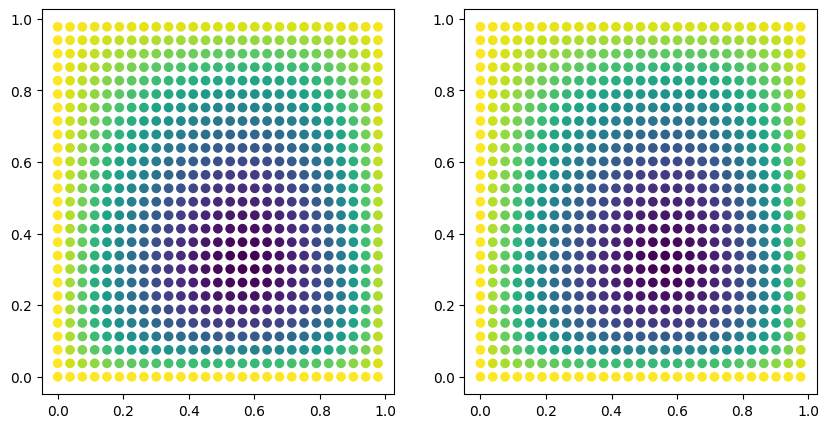

In [64]:
# Sanity check for solutions: The ordering sometimes can be messed up because of np.meshgrid (use indexing='ij') - Check if the 'scatter plot' shape corresponds to the contourf shape.  
fig, axs = plt.subplots(1,2, figsize=(10,5))
axs[0].scatter(Pred[:,0], Pred[:,1], c=usoln.reshape(400,400)[::step, ::step])
axs[1].scatter(Pred[:,0], Pred[:,1], c=uhat) 

## Uncertainty quantification

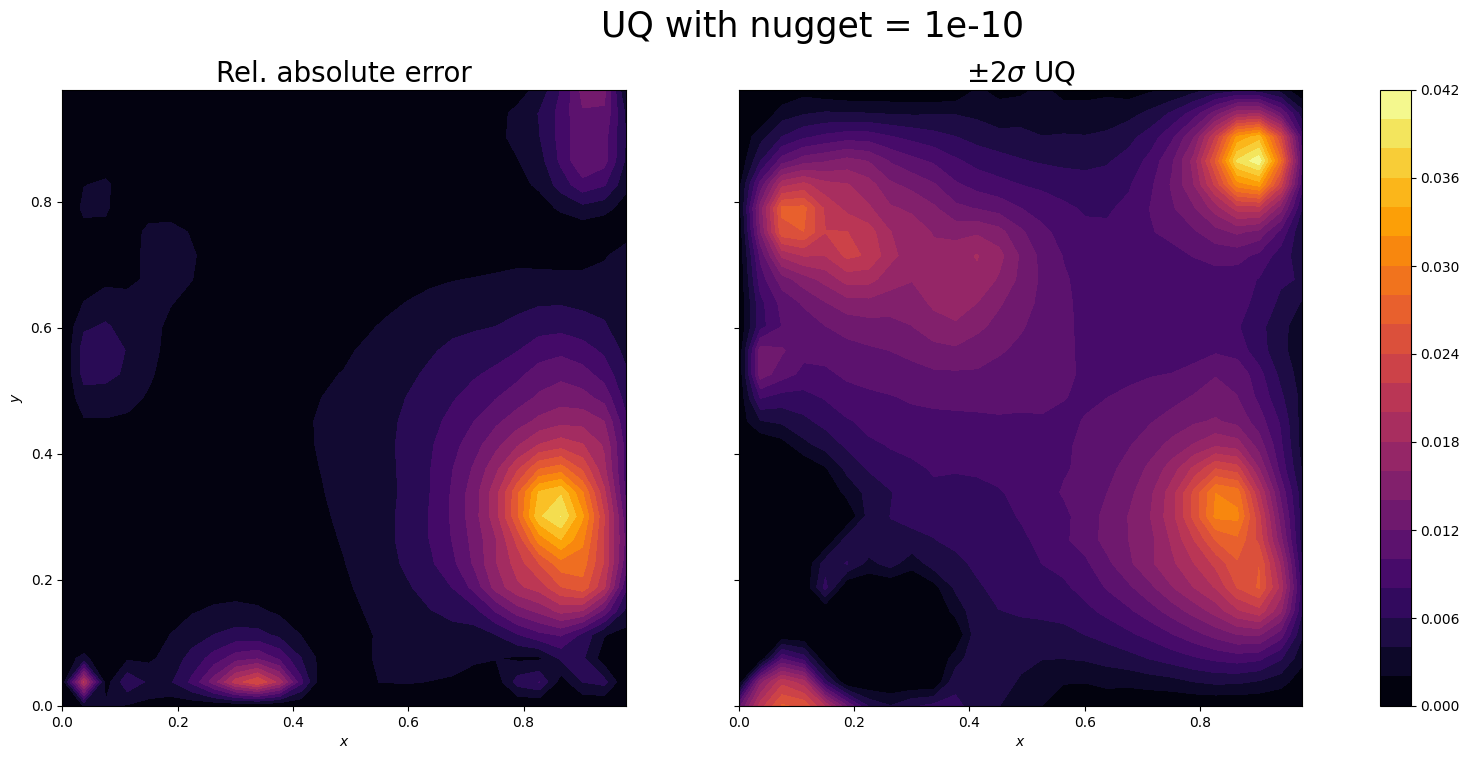

In [53]:
## Naive UQ computation (without LOOCV)
ktheta = lambda u, udash: k(u, udash, t=theta, s=1)
sigma = 1.0                 # Naively chosen

# Unconditional variance
Kstar = np.array(list(map(ktheta, Pred, Pred)))

# Conditional variance
nugget = 1e-10
Kplusinv = np.linalg.solve(Kplus + (nugget*Id), Id) 
Var = Kstar - np.diag(Hplus.T @ Kplusinv @ Hplus)
Var[Var<0] = 1e-10              # Negative variance set to 1e-10
Var = sigma**2 * Var
sd = np.sqrt(Var) 

# Visualize
fig, axs = plt.subplots(1,2, figsize=(20,8), sharey=True)
cm = axs[0].contourf(X[::step, ::step], Y[::step, ::step], np.abs(usoln.reshape(400, 400)[::step, ::step]-uhat.reshape(grid, grid))/(np.abs(usoln.reshape(400, 400)[::step, ::step])+0.1),
                   cmap='inferno', levels = 20)
# fig.colorbar(cm)
axs[0].set_title('Rel. absolute error', fontsize = 20)
axs[0].set_xlabel(r'$x$')
axs[0].set_ylabel(r'$y$')

cm = axs[1].contourf(X[::step, ::step], Y[::step, ::step], 2*sd.reshape(grid, grid), cmap='inferno', levels = 20)
# fig.colorbar(cm)
axs[1].set_title(r'$\pm 2 \sigma$ UQ', fontsize = 20)
axs[1].set_xlabel(r'$x$')

fig.colorbar(cm, ax=axs.ravel().tolist())

fig.suptitle(f'UQ with nugget = {nugget}', fontsize = 25)
plt.show()
